In [1]:
!pip install ggplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 124.4 kB/s eta 0:00:00


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [6]:
df= pd.read_csv('/content/Task 4 perform Cohort on CDNOW dataset.txt',
                names=["customer_id", 'date', 'quantity', 'price'], sep = "\s+")
df

,customer_id,date,quantity,price
0,1,19970101,1,11.77
1,2,19970112,1,12.00
2,2,19970112,5,77.00
3,3,19970102,2,20.76
4,3,19970330,2,20.76
...,...,...,...,...
69654,23568,19970405,4,83.74
69655,23568,19970422,1,14.99
69656,23569,19970325,2,25.74
69657,23570,19970325,3,51.12


In [7]:
df.drop(columns= ['customer_id','date']).describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,69659.0,2.410040,2.333924,1.0,1.00,2.00,3.0,99.00
price,69659.0,35.893648,36.281942,0.0,14.49,25.98,43.7,1286.01


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69659 entries, 0 to 69658
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  69659 non-null  int64  
 1   date         69659 non-null  int64  
 2   quantity     69659 non-null  int64  
 3   price        69659 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 2.1 MB


In [9]:
df.date = df.date.astype(str) ### we first need to change this to str or else auto infer won't work
df.date= pd.to_datetime(df.date, infer_datetime_format=True)

In [10]:
# Save this file as csv
df.to_csv('CDNOW.csv')
df.head(3)

,customer_id,date,quantity,price
0,1,1997-01-01,1,11.77
1,2,1997-01-12,1,12.00
2,2,1997-01-12,5,77.00


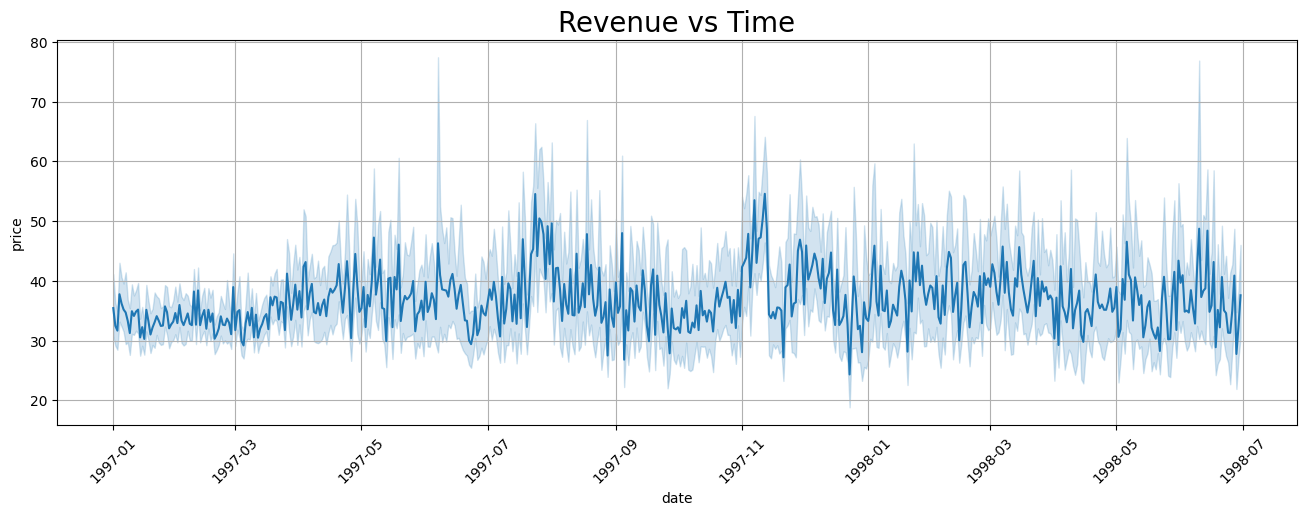

In [11]:
plt.figure(figsize=(16,5))
sns.lineplot(x='date', y='price', data=df)
plt.xticks(rotation=45)
plt.grid(True)
plt.title("Revenue vs Time", fontsize=20);

In [12]:
temp=pd.DataFrame()
temp['Year']= pd.DatetimeIndex(df['date']).year
temp['Revenue'] = df.price

'''
colors = sns.color_palette('pastel')
plt.pie(data, colors = colors)
plt.show()
'''
temp.groupby('Year').sum()

,Revenue
Year,
1997,2024161.26
1998,476154.37


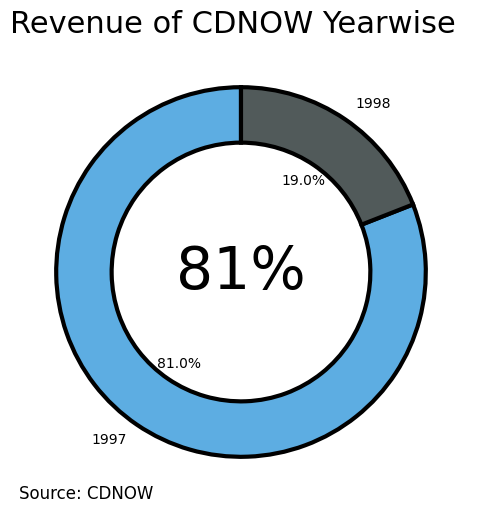

In [13]:
# Setting labels for items in Chart
year = ['1997', '1998']

# Setting size in Chart based on
# given values
revenue = [2024161.26, 476154.37]

# colors
colors = ['#5DADE2', '#515A5A']

#### Plotting
fig, ax = plt.subplots(figsize=(6, 6))
wedgeprops = {'width':0.3, 'edgecolor':'black', 'linewidth':3}
# Pie Chart
plt.pie(revenue, colors=colors, labels=year,
       wedgeprops=wedgeprops, startangle=90,autopct='%1.1f%%')

plt.text(0, 0, "81%", ha='center', va='center', fontsize=42)
plt.text(-1.2, -1.2, "Source: CDNOW", ha='left', va='center', fontsize=12)

plt.title('Revenue of CDNOW Yearwise', fontsize=22, loc='left')
# Displaying Chart
plt.show()

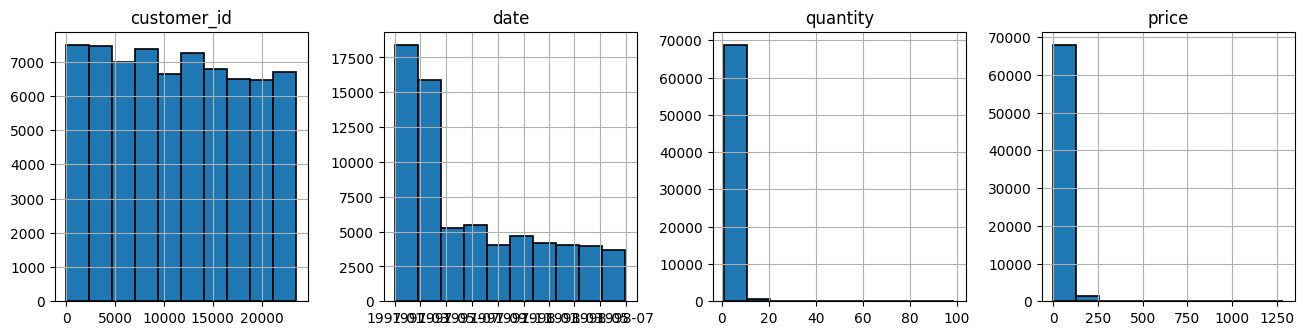

In [14]:
df.hist(layout=(1,4),figsize=(16,3.5), edgecolor='black', linewidth=1.2);

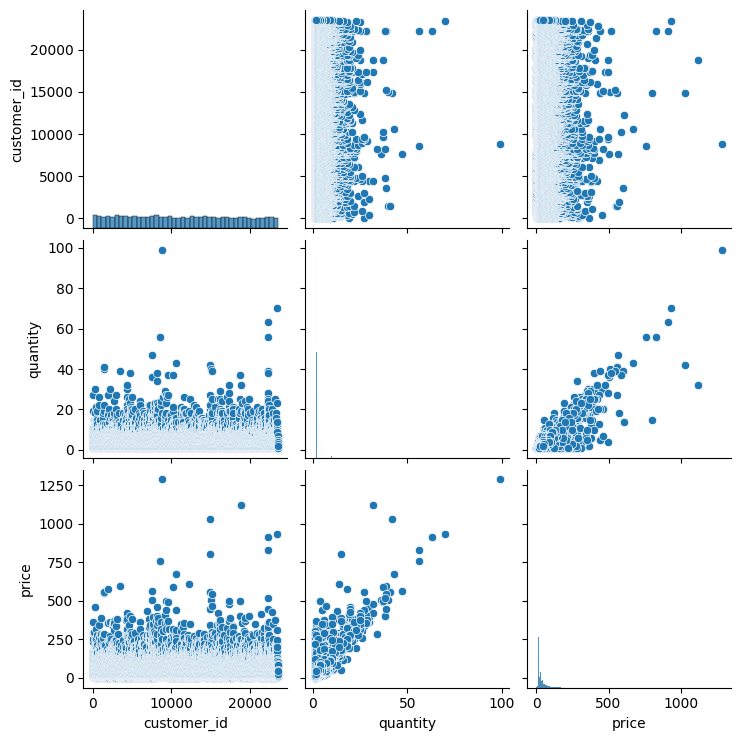

In [15]:
sns.pairplot(df);

**Cohort Analysis**

In [16]:
## Check avg spending by each customer
temp = df.drop('date',axis=1).groupby('customer_id').sum()
temp.describe()

,quantity,price
count,23570.000000,23570.000000
mean,7.122656,106.080426
std,16.983531,240.925195
min,1.000000,0.000000
25%,1.000000,19.970000
50%,3.000000,43.395000
75%,7.000000,106.475000
max,1033.000000,13990.930000


In [17]:
## Getting range of inital purchases
initial_purchase_df = df.sort_values(['customer_id','date']).groupby('customer_id').first()
initial_purchase_df

,date,quantity,price
customer_id,,,
1,1997-01-01,1,11.77
2,1997-01-12,1,12.00
3,1997-01-02,2,20.76
4,1997-01-01,2,29.33
5,1997-01-01,2,29.33
...,...,...,...
23566,1997-03-25,2,36.00
23567,1997-03-25,1,20.97
23568,1997-03-25,1,22.97


In [18]:
print("CDNOW's first new customer order in this dataset",initial_purchase_df.date.min())
print("CDNOW's last new customer order in this dataset",initial_purchase_df.date.max())

CDNOW's first new customer order in this dataset 1997-01-01 00:00:00
CDNOW's last new customer order in this dataset 1997-03-25 00:00:00


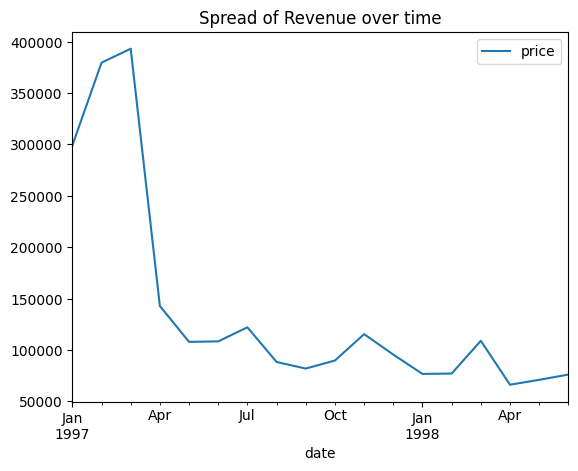

In [19]:
## Here I am setting my date as index -> than picking price column and resampling it with rule ="MS" and then finally plotting it
## Resample ( rule : the offset string or object representing target conversion. "MS" : month start frequency)

df.reset_index().set_index('date')[['price']].resample(rule="MS").sum().plot(title=('Spread of Revenue over time'));

In [20]:
# To track the purchasing behaviour of customers lets micro analyse 1st 15 customers
ids= df.customer_id.unique()
ids_selected = ids[0:10]

In [21]:
df_sut_id_subset = df[df['customer_id'].isin(ids_selected)].groupby(['customer_id','date']).sum().reset_index()
# df_sut_id_subset

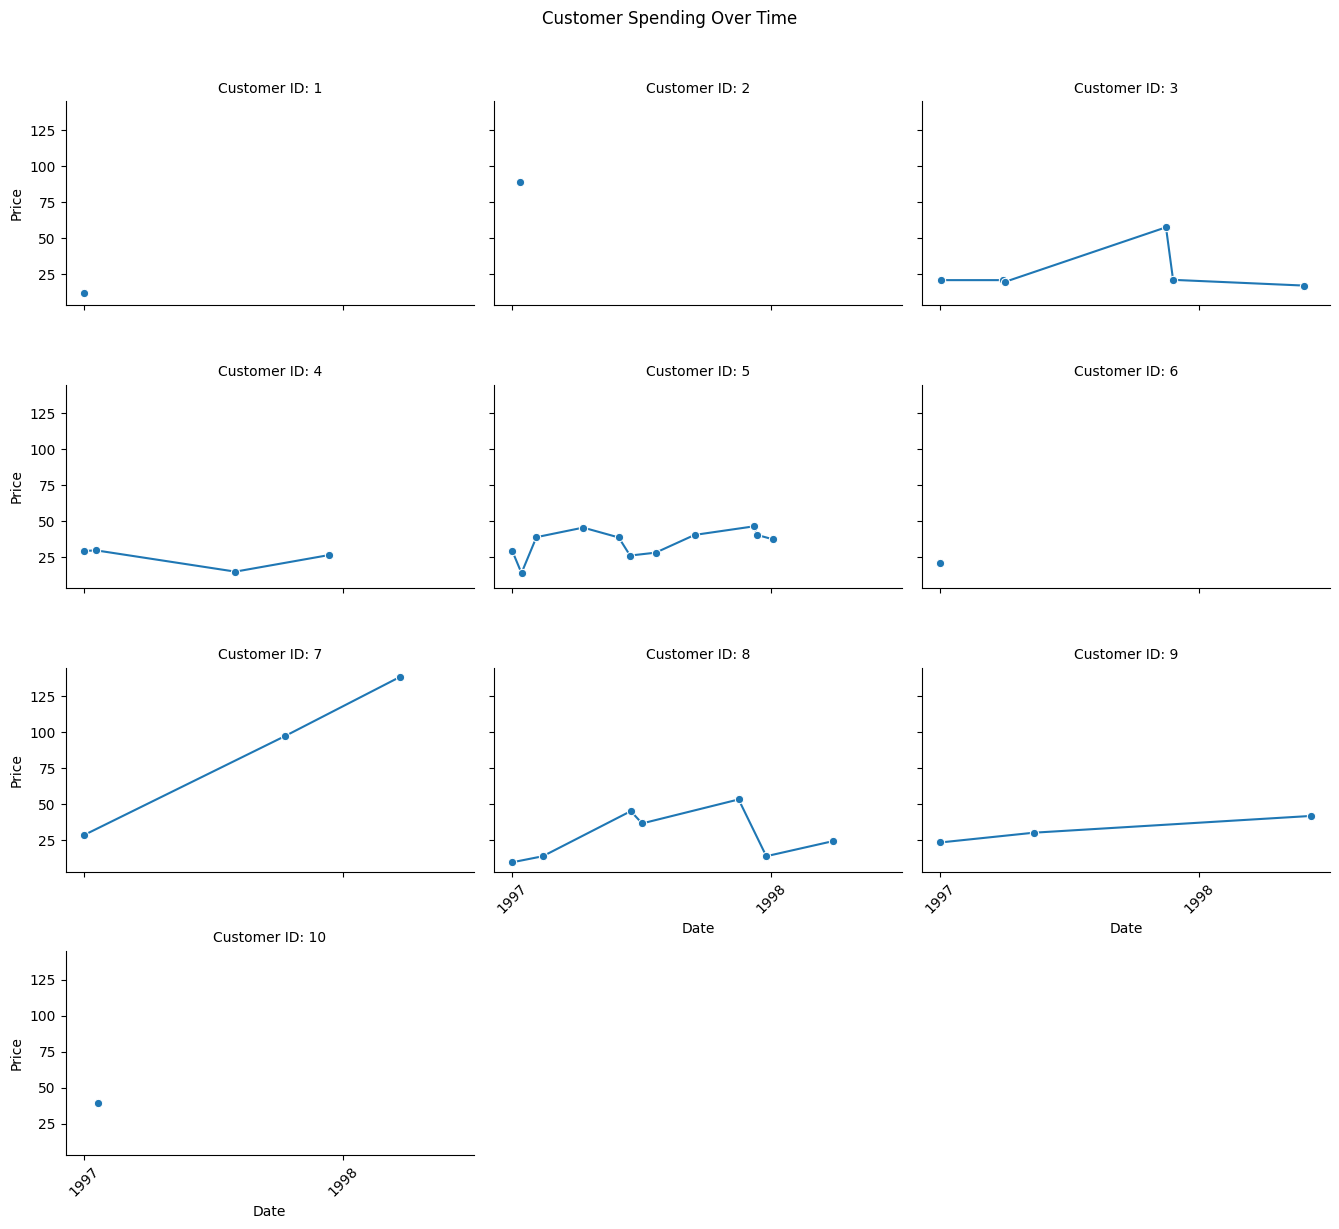

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.relplot(
    data=df_sut_id_subset,
    x='date',
    y='price',
    col='customer_id',
    kind='line',
    marker='o',
    col_wrap=3,
    height=3, aspect=1.5
)

g.set_axis_labels("Date", "Price")
g.set_titles("Customer ID: {col_name}")

for ax in g.axes.flat:
    ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Customer Spending Over Time', y=1.02)
plt.tight_layout()
plt.show()

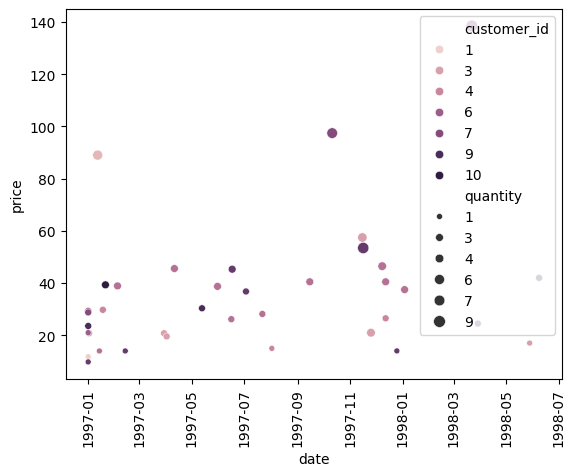

In [24]:
sns.scatterplot(y='price', x='date', data =df_sut_id_subset, size='quantity', hue='customer_id')
plt.xticks(rotation=90);

**Data Preprocessing**

In [25]:
n_days = 90
max_date = df['date'].max()
cutoff = max_date - pd.to_timedelta(n_days, unit = 'd')

temporal_in_df = df[df['date']<=cutoff]
temporal_out_df = df[df['date']>cutoff]

print("temporal_in_df")
display(temporal_in_df.head(3))
print()
print("temporal_out_df")
display(temporal_out_df.head(3))

temporal_in_df


,customer_id,date,quantity,price
0,1,1997-01-01,1,11.77
1,2,1997-01-12,1,12.00
2,2,1997-01-12,5,77.00



temporal_out_df


,customer_id,date,quantity,price
8,3,1998-05-28,1,16.99
38,9,1998-06-08,2,41.98
68,25,1998-04-17,1,12.99


Make Targets from out data

In [27]:
## Create a target df: drop quantity, -> groupby Customer_id -> Sum -> rename price to spend_90_total and assign flag=1 to all rows

targets_df = temporal_out_df.groupby('customer_id')['price'].sum().rename('Spend_90_total').to_frame().assign(spend_90_flag= 1)
targets_df.head(3)

,Spend_90_total,spend_90_flag
customer_id,,
3,16.99,1
9,41.98,1
25,73.43,1


**FRM**

Frequency (Make Frequency(Count) Feature into Data)

In [28]:
frequency_feature_df= temporal_in_df[['customer_id', 'date']].groupby('customer_id') \
    .count().set_axis(['frequency'], axis=1)

frequency_feature_df.head(3)

,frequency
customer_id,
1,1
2,2
3,5


Recency (Make Recency (Date) Features from in data)

In [29]:
max_date = temporal_in_df['date'].max()

recency_feature_df= temporal_in_df[['customer_id', 'date']].groupby('customer_id') \
    .apply(lambda x: (x['date'].max()- max_date)/pd.to_timedelta(1, 'day')).to_frame().set_axis(['recency'],axis=1)

recency_feature_df.head(3)

,recency
customer_id,
1,-455.0
2,-444.0
3,-127.0


-ve sign in recency means n no of days ago. we can also make it absolute

In [30]:
recency_feature_df= recency_feature_df.abs()

Monetary (Make Price Feature into Data)

In [31]:
price_features_df = temporal_in_df.groupby('customer_id').aggregate({'price':['sum', 'mean']}).set_axis(['price_sum', 'price_mean'], axis=1)

price_features_df.head()

,price_sum,price_mean
customer_id,,
1,11.77,11.770000
2,89.00,44.500000
3,139.47,27.894000
4,100.50,25.125000
5,385.61,35.055455


Combine all features

In [32]:
features_df = pd.concat([frequency_feature_df,recency_feature_df,price_features_df], axis=1)\
    .merge(targets_df, left_index= True, right_index=True, how='left').fillna(0)
features_df

,frequency,recency,price_sum,price_mean,Spend_90_total,spend_90_flag
customer_id,,,,,,
1,1,455.0,11.77,11.770000,0.00,0.0
2,2,444.0,89.00,44.500000,0.00,0.0
3,5,127.0,139.47,27.894000,16.99,1.0
4,4,110.0,100.50,25.125000,0.00,0.0
5,11,88.0,385.61,35.055455,0.00,0.0
...,...,...,...,...,...,...
23566,1,372.0,36.00,36.000000,0.00,0.0
23567,1,372.0,20.97,20.970000,0.00,0.0
23568,3,344.0,121.70,40.566667,0.00,0.0


Remember I kept flag= 1 for those who spend within 90 days and rest are marked 0 this will help us while calculating probability

**Modeling**

Find out?

What will be the customers spend in the next 90 days? Regression

What is the probability of a customer to make a purchase in next 90 days? Classification

In [33]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import GridSearchCV

In [34]:
X = features_df[['recency', 'frequency', 'price_sum', 'price_mean']]
y_spend = features_df['Spend_90_total']

In [35]:
xgb_reg = XGBRegressor(objective = "reg:squarederror", reandom_state = 7)

In [36]:
xgb_reg_model = GridSearchCV(estimator = xgb_reg, param_grid=dict(n_estimators=[50,100, 200],learning_rate = [0.01,0.1,0.2,0.5], max_depth = [3, 4, 5]),
                            scoring='neg_mean_absolute_error', refit= True,cv=10)

In [37]:
%%time
xgb_reg_model.fit(X,y_spend)

CPU times: user 1min 43s, sys: 999 ms, total: 1min 44s
Wall time: 1min 6s


GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.5],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [38]:
xgb_reg_model.best_estimator_

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [39]:
xgb_reg_model.best_score_

np.float64(-10.748035673112854)

In [40]:
xgb_reg_model.best_params_

{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}

In [41]:
predictions_reg = xgb_reg_model.predict(X)

**Classification problem: What is the probability of a customer to make a purchase in next 90 days?**

In [42]:
y_prob = features_df['spend_90_flag']

In [43]:
xgb_clf = XGBClassifier(objective ='binary:logistic', random_state=7)

In [44]:
xgb_clf_model = GridSearchCV(estimator = xgb_clf, param_grid=dict(n_estimators=[50,100, 200],learning_rate = [0.01,0.001,0.2,0.5], max_depth = [1, 3, 4]),
                            scoring='roc_auc', refit= True,cv=10)

In [45]:
%%time
xgb_clf_model.fit(X,y_prob)

CPU times: user 2min 1s, sys: 837 ms, total: 2min 2s
Wall time: 1min 18s


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=No...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.001, 0.2, 0.5],
                         'max_depth': [1, 3, 4],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

In [46]:
xgb_clf_model.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [47]:
xgb_clf_model.best_score_

np.float64(0.8405452596706879)

In [48]:
xgb_clf_model.best_params_

{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}

In [49]:
predictions_clf = xgb_clf_model.predict(X)
predictions_clf

array([0, 0, 0, ..., 0, 0, 0])

In [50]:
### This will return probability of customer purchashing from CDNOW site
predictions_clf_probability = xgb_clf_model.predict_proba(X)
predictions_clf_probability

array([[0.9574997 , 0.04250029],
       [0.9555764 , 0.04442359],
       [0.739364  , 0.260636  ],
       ...,
       [0.89532924, 0.10467079],
       [0.9516333 , 0.04836674],
       [0.9139278 , 0.08607224]], dtype=float32)

**Feature importance for business insights**

In [51]:
## Importance || Spend Amount Model
imp_spend_amount_dic = xgb_reg_model.best_estimator_.get_booster().get_score(importance_type='gain')

In [52]:
imp_spend_amount_df= pd.DataFrame(data= {'feature': list(imp_spend_amount_dic.keys()),
                                        'value':list(imp_spend_amount_dic.values())})

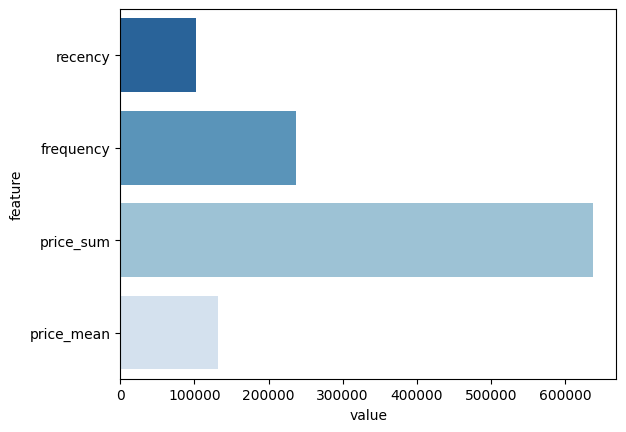

In [53]:
sns.barplot(y='feature', x= 'value', data= imp_spend_amount_df, palette='Blues_r');


Price sum is most important when we try to calculate regression. Thus we need to encourage customer to spend more

**Feature Importance for Probability Model**

In [54]:
## Importance || Spend Amount Model
imp_spend_prob_dic = xgb_clf_model.best_estimator_.get_booster().get_score(importance_type='gain')

In [55]:
imp_spend_prob_df= pd.DataFrame(data= {'feature': list(imp_spend_prob_dic.keys()),
                                        'value':list(imp_spend_prob_dic.values())})

In [56]:
imp_spend_prob_df

,feature,value
0,recency,153.363922
1,frequency,71.351334
2,price_sum,5.302988
3,price_mean,3.514341


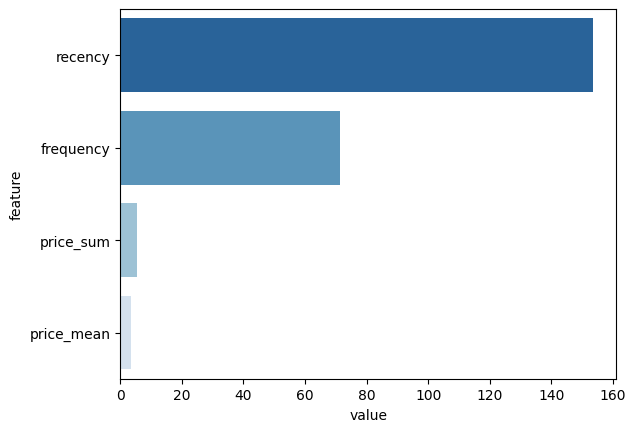

In [57]:
sns.barplot(y='feature', x= 'value', data= imp_spend_prob_df, palette='Blues_r');

When we checking probability of customer of revisiting site We need to encourage customers to buy more frequently compared to buy high value products

In [58]:
## Exporting featured DataFrame
features_df.to_csv('Featured_eng_df')